In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

df = pd.read_csv("Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

features = [
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day'
]

target = 'addicted_label'

X = df[features]
y = df[target]

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

model.save("model/addiction_model.h5")

joblib.dump(scaler, "model/scaler.pkl")

print("모델 및 스케일러 저장 완료")

Epoch 1/50


c:\aisource\.venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8600 - loss: 0.3218 - val_accuracy: 0.9092 - val_loss: 0.1962
Epoch 2/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9100 - loss: 0.2014 - val_accuracy: 0.9117 - val_loss: 0.1715
Epoch 3/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9142 - loss: 0.1861 - val_accuracy: 0.9108 - val_loss: 0.1643
Epoch 4/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9198 - loss: 0.1726 - val_accuracy: 0.9183 - val_loss: 0.1581
Epoch 5/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9265 - loss: 0.1636 - val_accuracy: 0.9175 - val_loss: 0.1513
Epoch 6/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9246 - loss: 0.1568 - val_accuracy: 0.9217 - val_loss: 0.1470
Epoch 7/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9242 - loss: 0.1533 - val_accuracy: 0.9283 - val_loss: 0.1446
Epoch 8/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9302 - loss: 0.1470 - val_accuracy: 0.9250 - val_

모델 및 스케일러 저장 완료


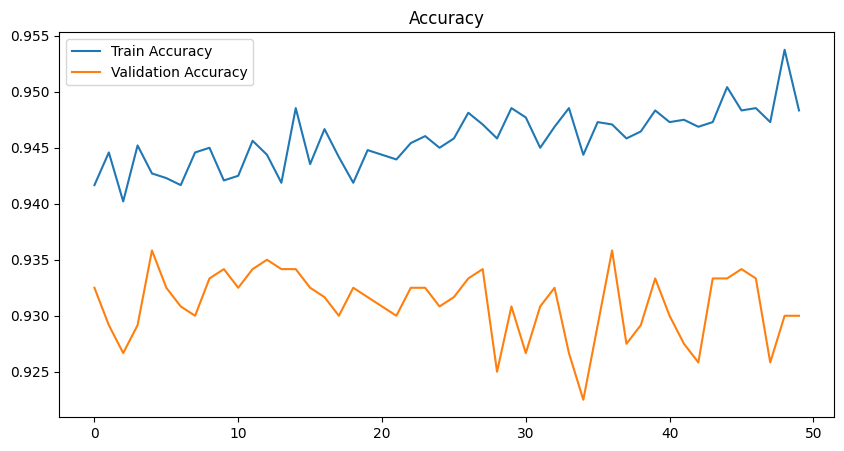

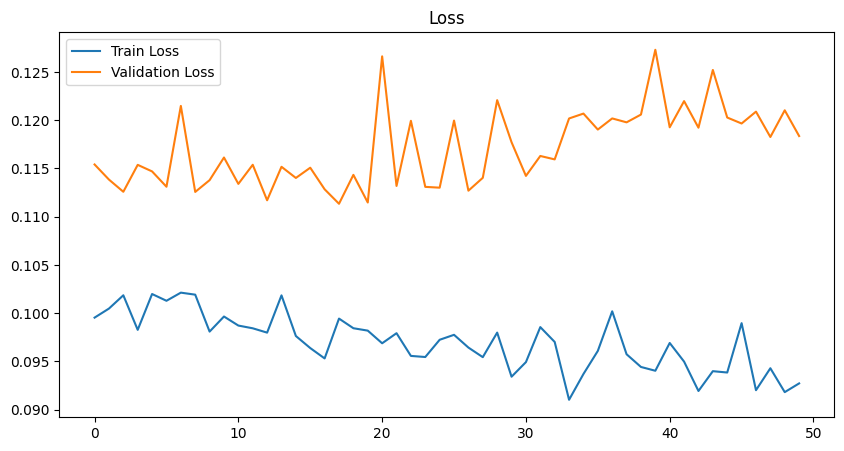

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()
plt.savefig("accuracy.png", dpi=300)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.savefig("loss.png", dpi=300)
plt.show()

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


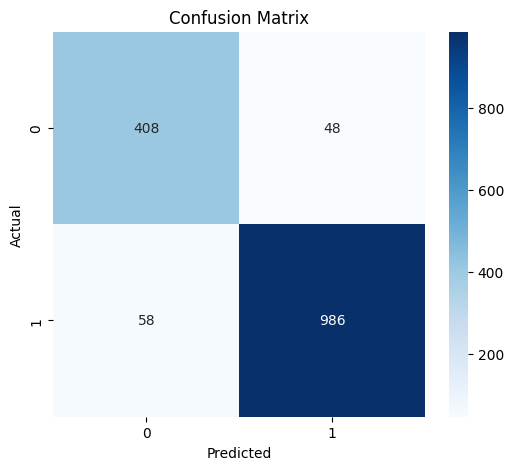

In [4]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = (model.predict(X_test_scaled) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


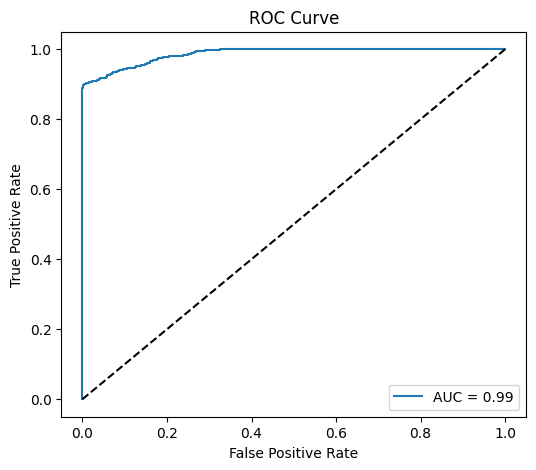

In [5]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_prob = model.predict(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


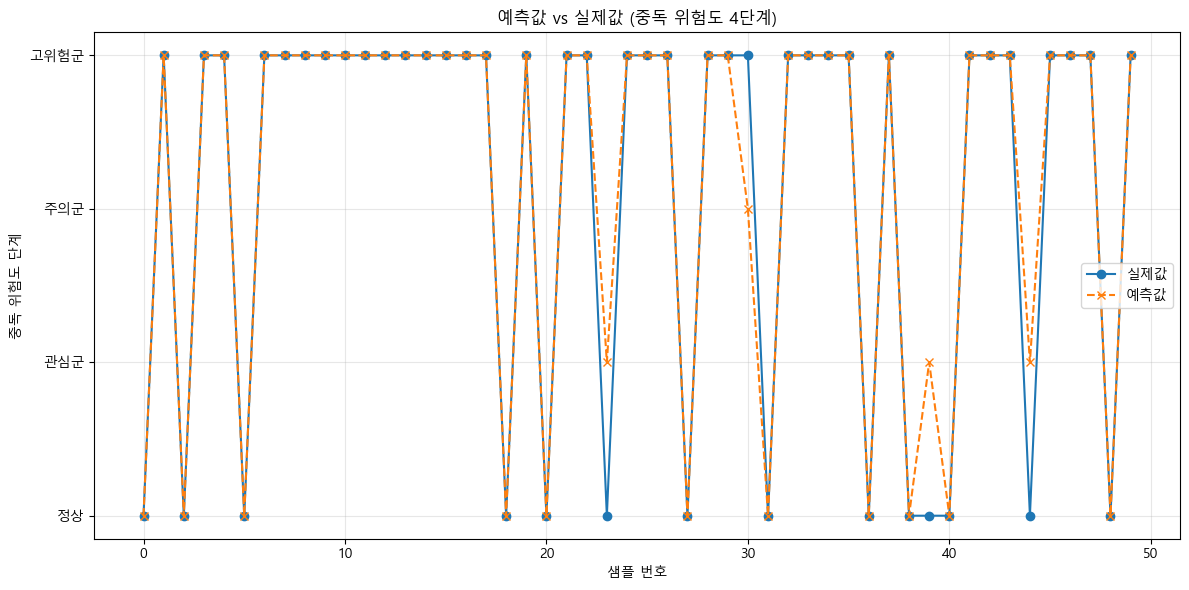

In [9]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

model = load_model("model/addiction_model.h5")
scaler = joblib.load("model/scaler.pkl")

df = pd.read_csv("Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

features = [
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day'
]

target = 'addicted_label'

X = df[features]
y = df[target]

_, X_test, _, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_test_scaled = scaler.transform(X_test)

y_pred_prob = model.predict(X_test_scaled).flatten()

def classify_risk(prob):
    if prob < 0.25:
        return 0  # 정상
    elif prob < 0.50:
        return 1  # 관심군
    elif prob < 0.75:
        return 2  # 주의군
    else:
        return 3  # 고위험군

y_pred_class = np.array([classify_risk(p) for p in y_pred_prob])

y_true_class = np.array([classify_risk(p) for p in y_test])

plot_df = pd.DataFrame({
    'Actual': y_true_class,
    'Predicted': y_pred_class
}).reset_index(drop=True).head(50)

# 그래프
plt.figure(figsize=(12,6))
plt.plot(plot_df.index, plot_df['Actual'], label='실제값', marker='o')
plt.plot(plot_df.index, plot_df['Predicted'], label='예측값', linestyle='--', marker='x')

plt.yticks(
    [0,1,2,3],
    ['정상', '관심군', '주의군', '고위험군']
)

plt.xlabel("샘플 번호")
plt.ylabel("중독 위험도 단계")
plt.title("예측값 vs 실제값 (중독 위험도 4단계)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("actual_vs_predicted_4class.png", dpi=300, bbox_inches='tight')
plt.show()